In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    VotingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score
import joblib, os

# ── Plot style
plt.rcParams.update({
    'figure.facecolor': '#0d1526',
    'axes.facecolor':   '#111927',
    'axes.edgecolor':   '#1e2d45',
    'axes.labelcolor':  '#7b92b0',
    'axes.titlecolor':  '#e2eaf6',
    'axes.titlesize':   12,
    'xtick.color':      '#445669',
    'ytick.color':      '#445669',
    'text.color':       '#e2eaf6',
    'grid.color':       '#1e2d45',
    'grid.alpha':       0.6,
    'figure.dpi':       110,
    'font.size':        10,
})
COLORS = dict(blue='#0ea5e9', green='#22c55e', red='#ef4444',
              gold='#f59e0b', purple='#a78bfa', cyan='#06b6d4')

os.makedirs('models', exist_ok=True)
print('✅ Imports complete')

✅ Imports complete


In [ ]:
# load the data
df = pd.read_csv('data/nepse_stock_prices.csv', parse_dates=['published_date'])
df = df.sort_values(['Symbol', 'published_date']).reset_index(drop=True)

print('═' * 50)
print('  NEPSE Dataset Overview')
print('═' * 50)
print(f'  Total rows    : {len(df):,}')
print(f'  Symbols       : {df["Symbol"].nunique()}')
print(f'  Date range    : {df["published_date"].min().date()} → {df["published_date"].max().date()}')
print(f'  Columns       : {df.columns.tolist()}')
print(f'  Missing values: {df.isnull().sum().sum()}')
print('═' * 50)

df.head()

══════════════════════════════════════════════════
  NEPSE Dataset Overview
══════════════════════════════════════════════════
  Total rows    : 250,445
  Symbols       : 124
  Date range    : 2003-06-06 → 2025-08-07
  Columns       : ['published_date', 'open', 'high', 'low', 'close', 'per_change', 'traded_quantity', 'traded_amount', 'status', 'Symbol']
  Missing values: 87
══════════════════════════════════════════════════


,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status,Symbol
0,2010-09-16,117.0,122.0,116.0,120.0,NaN,5280.0,0.0,0,ADBL
1,2010-09-19,120.0,120.0,116.0,118.0,-1.67,2648.0,0.0,0,ADBL
2,2010-09-20,118.0,119.0,116.0,118.0,0.00,2346.0,0.0,0,ADBL
3,2010-09-21,118.0,118.0,115.0,116.0,-1.69,7160.0,0.0,0,ADBL
4,2010-09-23,116.0,120.0,117.0,120.0,3.45,8417.0,0.0,0,ADBL


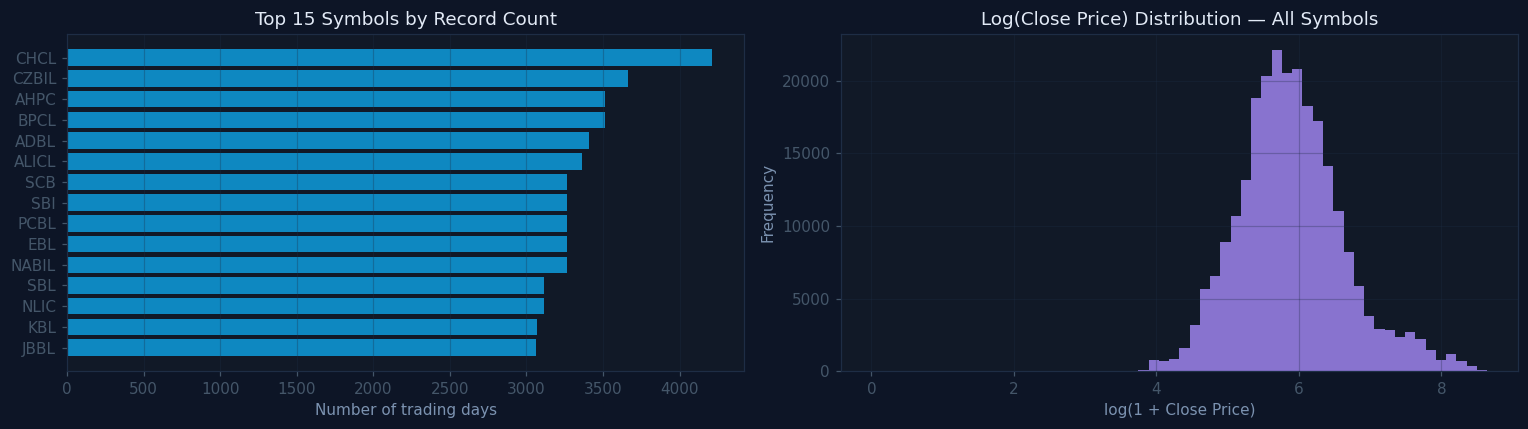

Dataset spans 124 symbols | 250,445 trading records


In [3]:
# Top symbols by data count
top_syms = df.groupby('Symbol').size().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Symbols by count
ax = axes[0]
ax.barh(top_syms.index[::-1], top_syms.values[::-1],
        color=COLORS['blue'], alpha=0.8)
ax.set_title('Top 15 Symbols by Record Count')
ax.set_xlabel('Number of trading days')
ax.grid(True, alpha=0.3, axis='x')

# Price distribution across all symbols (close)
ax = axes[1]
log_prices = np.log1p(df['close'].dropna())
ax.hist(log_prices, bins=60, color=COLORS['purple'], alpha=0.8, edgecolor='none')
ax.set_title('Log(Close Price) Distribution — All Symbols')
ax.set_xlabel('log(1 + Close Price)')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight', facecolor='#0d1526')
plt.show()
print(f'Dataset spans {df["Symbol"].nunique()} symbols | {len(df):,} trading records')

In [ ]:
# feature engineering
def compute_rsi(series, period=14):
    """Relative Strength Index — momentum oscillator (0-100)."""
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss.replace(0, np.nan)
    return (100 - 100 / (1 + rs)).fillna(50)  # fill NaN with neutral 50


def engineer_features(group):
    """
    Build 31 technical features for a single symbol's price history.
    All features are ratio/percentage based for cross-symbol comparability.
    """
    g = group.copy()
    c = g['close']
    v = g['traded_quantity']

    # ── 1. Return features (price momentum)
    g['r1']  = c.pct_change(1).clip(-0.5, 0.5)    # 1-day return
    g['r3']  = c.pct_change(3).clip(-0.5, 0.5)    # 3-day return
    g['r5']  = c.pct_change(5).clip(-0.5, 0.5)    # 5-day return
    g['r10'] = c.pct_change(10).clip(-0.5, 0.5)   # 10-day return
    g['r20'] = c.pct_change(20).clip(-0.5, 0.5)   # 20-day return

    # ── 2. Moving averages
    ma5  = c.rolling(5).mean()
    ma10 = c.rolling(10).mean()
    ma20 = c.rolling(20).mean()
    ma50 = c.rolling(50).mean()
    g['ma5'] = ma5; g['ma10'] = ma10
    g['ma20'] = ma20; g['ma50'] = ma50

    # ── 3. Price-to-MA ratios (normalized, scale-independent)
    g['p_ma5']  = (c / ma5.replace(0, np.nan)).clip(0.5, 2.0)
    g['p_ma10'] = (c / ma10.replace(0, np.nan)).clip(0.5, 2.0)
    g['p_ma20'] = (c / ma20.replace(0, np.nan)).clip(0.5, 2.0)
    g['p_ma50'] = (c / ma50.replace(0, np.nan)).clip(0.5, 2.0)

    # ── 4. MA crossover signals (golden cross / death cross)
    g['ma5_ma20']  = (ma5  / ma20.replace(0, np.nan)).clip(0.5, 2.0)
    g['ma10_ma50'] = (ma10 / ma50.replace(0, np.nan)).clip(0.5, 2.0)

    # ── 5. MACD (Moving Average Convergence Divergence)
    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    macd  = (ema12 - ema26) / c.replace(0, np.nan)
    g['macd']      = macd.clip(-0.2, 0.2)
    g['macd_sig']  = g['macd'].ewm(span=9, adjust=False).mean()
    g['macd_hist'] = (g['macd'] - g['macd_sig']).clip(-0.1, 0.1)

    # ── 6. Bollinger Bands
    bb_std = c.rolling(20).std().replace(0, 1e-6)
    g['bb_pos']   = ((c - (ma20 - 2*bb_std)) / (4*bb_std)).clip(-1, 3)
    g['bb_width'] = (4 * bb_std / ma20.replace(0, np.nan)).clip(0, 1)

    # ── 7. RSI (momentum oscillator)
    g['rsi14'] = compute_rsi(c, 14)
    g['rsi7']  = compute_rsi(c, 7)

    # ── 8. Volume ratios
    g['vr5']  = (v / v.rolling(5).mean().replace(0, 1)).clip(0, 10)
    g['vr10'] = (v / v.rolling(10).mean().replace(0, 1)).clip(0, 10)

    # ── 9. Candlestick features
    g['hl_r'] = ((g['high'] - g['low']) / c.replace(0, np.nan)).clip(0, 0.5)
    g['oc_r'] = ((g['open'] - c)        / c.replace(0, np.nan)).clip(-0.2, 0.2)

    # ── 10. Volatility
    g['vol10'] = g['r1'].rolling(10).std().clip(0, 0.2)
    g['vol20'] = g['r1'].rolling(20).std().clip(0, 0.2)

    # ── 11. Momentum (price distance from past)
    g['mom5']  = ((c - c.shift(5))  / c.replace(0, np.nan)).clip(-0.5, 0.5)
    g['mom10'] = ((c - c.shift(10)) / c.replace(0, np.nan)).clip(-0.5, 0.5)
    g['mom20'] = ((c - c.shift(20)) / c.replace(0, np.nan)).clip(-0.5, 0.5)

    # ── 12. Lag ratios (recent price context)
    for lag in [1, 2, 3, 5]:
        g[f'lag{lag}'] = (c.shift(lag) / c.replace(0, np.nan)).clip(0.5, 2.0)

    # ═══════════════════════════════════════════
    # TARGET LABELS
    # ═══════════════════════════════════════════
    # Task 1 — TREND: Is MA5 above MA20 RIGHT NOW?
    #   1 = Uptrend (MA5 > MA20)  |  0 = Downtrend
    #   This is a CURRENT-DAY label — no future data used.
    g['trend_label'] = (ma5 > ma20).astype(int)

    # Task 2 — DIRECTION: Will price be higher in 3 trading days?
    #   1 = Price goes up  |  0 = Price goes down or flat
    g['dir_label'] = (c.shift(-3) > c).astype(int)

    return g


print('Engineering features for all 124 symbols...')
all_df = df.groupby('Symbol', group_keys=False).apply(engineer_features)
all_df = all_df.replace([np.inf, -np.inf], np.nan)

FEATURE_COLS = [
    'r1','r3','r5','r10','r20',
    'p_ma5','p_ma10','p_ma20','p_ma50',
    'ma5_ma20','ma10_ma50',
    'macd','macd_sig','macd_hist',
    'bb_pos','bb_width',
    'rsi14','rsi7',
    'vr5','vr10',
    'hl_r','oc_r',
    'vol10','vol20',
    'mom5','mom10','mom20',
    'lag1','lag2','lag3','lag5'
]

all_df = all_df.dropna(subset=FEATURE_COLS + ['trend_label', 'dir_label'])
print(f'✅ Features ready: {len(all_df):,} samples × {len(FEATURE_COLS)} features')
print(f'   Feature list: {FEATURE_COLS}')

Engineering features for all 124 symbols...
✅ Features ready: 244,347 samples × 31 features
   Feature list: ['r1', 'r3', 'r5', 'r10', 'r20', 'p_ma5', 'p_ma10', 'p_ma20', 'p_ma50', 'ma5_ma20', 'ma10_ma50', 'macd', 'macd_sig', 'macd_hist', 'bb_pos', 'bb_width', 'rsi14', 'rsi7', 'vr5', 'vr10', 'hl_r', 'oc_r', 'vol10', 'vol20', 'mom5', 'mom10', 'mom20', 'lag1', 'lag2', 'lag3', 'lag5']


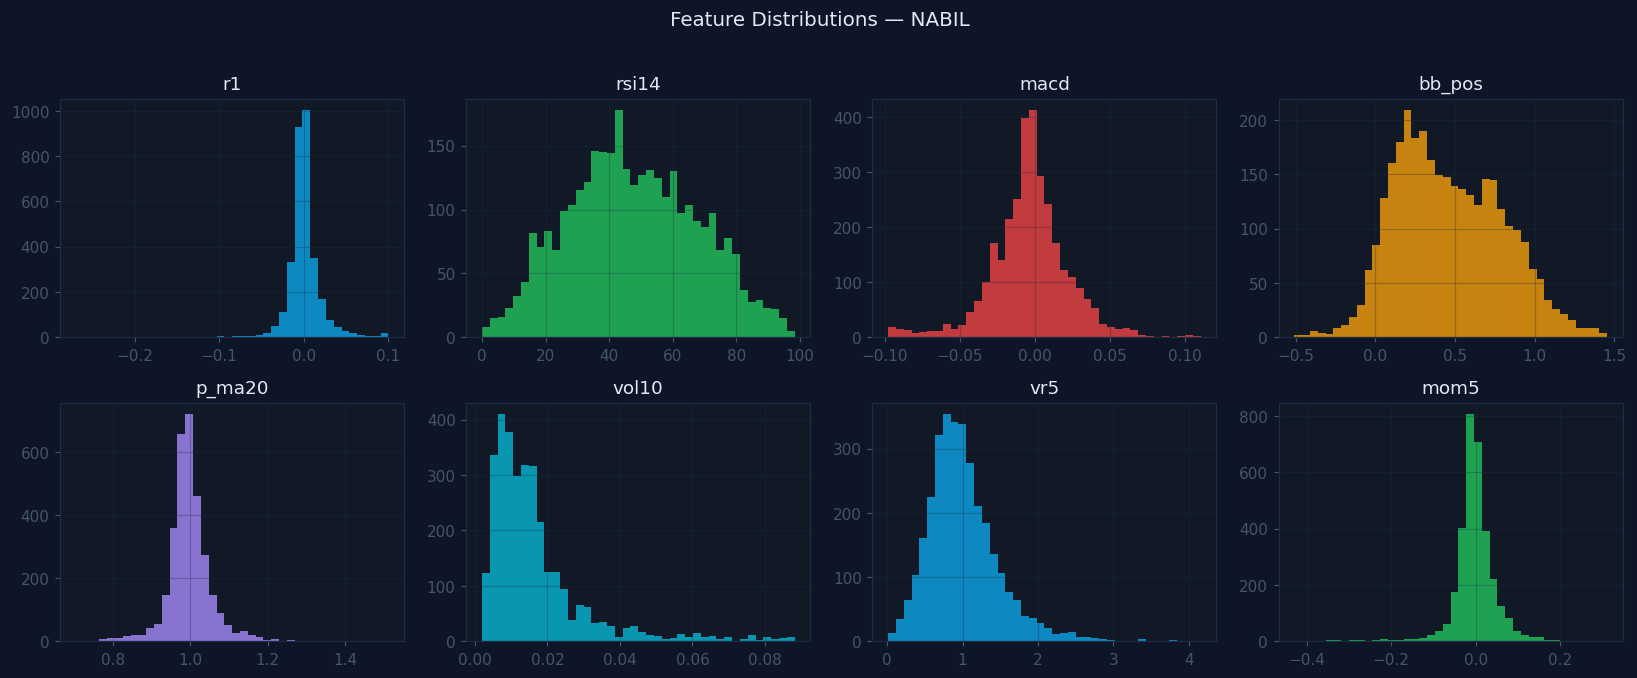

In [5]:
# Visualise feature distributions for NABIL
nabil = all_df[all_df['Symbol'] == 'NABIL'].copy()

show_feats = ['r1', 'rsi14', 'macd', 'bb_pos', 'p_ma20', 'vol10', 'vr5', 'mom5']
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()

for i, feat in enumerate(show_feats):
    axes[i].hist(nabil[feat].dropna(), bins=40,
                 color=list(COLORS.values())[i % 6], alpha=0.8, edgecolor='none')
    axes[i].set_title(feat)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Feature Distributions — NABIL', fontsize=13, color='#e2eaf6', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight', facecolor='#0d1526')
plt.show()

In [ ]:
# train test and split
CUTOFF = pd.Timestamp('2023-01-01')

X = all_df[FEATURE_COLS].values.astype(float)
y_trend = all_df['trend_label'].values
y_dir   = all_df['dir_label'].values

train_mask = (all_df['published_date'] < CUTOFF).values
test_mask  = ~train_mask

# Feature scaling (zero mean, unit variance)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X[train_mask])   # fit ONLY on train
X_test  = scaler.transform(X[test_mask])        # transform test with train stats

y_train_trend, y_test_trend = y_trend[train_mask], y_trend[test_mask]
y_train_dir,   y_test_dir   = y_dir[train_mask],   y_dir[test_mask]

print('═' * 45)
print(f'  Training samples : {train_mask.sum():>8,}  (pre 2023)')
print(f'  Testing  samples : {test_mask.sum():>8,}  (2023+)')
print(f'  Features         : {len(FEATURE_COLS):>8}')
print('─' * 45)
print(f'  Trend  class balance  : Down={y_test_trend.sum()==0} '
      f'  0={int((y_test_trend==0).sum()):,} | 1={int((y_test_trend==1).sum()):,}')
print(f'  Dir3d  class balance  : '
      f'  0={int((y_test_dir==0).sum()):,} | 1={int((y_test_dir==1).sum()):,}')
baseline_trend = max((y_test_trend==0).sum(), (y_test_trend==1).sum()) / len(y_test_trend)
baseline_dir   = max((y_test_dir==0).sum(),   (y_test_dir==1).sum())   / len(y_test_dir)
print(f'  Baseline (majority)   : Trend={baseline_trend*100:.1f}%  Dir={baseline_dir*100:.1f}%')
print('═' * 45)

═════════════════════════════════════════════
  Training samples :  180,896  (pre 2023)
  Testing  samples :   63,451  (2023+)
  Features         :       31
─────────────────────────────────────────────
  Trend  class balance  : Down=False   0=33,493 | 1=29,958
  Dir3d  class balance  :   0=34,815 | 1=28,636
  Baseline (majority)   : Trend=52.8%  Dir=54.9%
═════════════════════════════════════════════


In [7]:
# ─── Individual models ──────────────────────────────────────────

print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = 15,
    min_samples_leaf= 3,
    max_features    = 'sqrt',
    class_weight    = 'balanced',
    random_state    = 42,
    n_jobs          = -1
)
rf.fit(X_train, y_train_trend)
acc_rf = accuracy_score(y_test_trend, rf.predict(X_test))
print(f'  Random Forest     : {acc_rf*100:.2f}%')

print('Training Extra Trees...')
et = ExtraTreesClassifier(
    n_estimators    = 300,
    max_depth       = 15,
    min_samples_leaf= 3,
    max_features    = 'sqrt',
    class_weight    = 'balanced',
    random_state    = 42,
    n_jobs          = -1
)
et.fit(X_train, y_train_trend)
acc_et = accuracy_score(y_test_trend, et.predict(X_test))
print(f'  Extra Trees       : {acc_et*100:.2f}%')

print('Training Gradient Boosting...')
gb = GradientBoostingClassifier(
    n_estimators    = 200,
    max_depth       = 5,
    learning_rate   = 0.05,
    subsample       = 0.8,
    min_samples_leaf= 5,
    random_state    = 42
)
gb.fit(X_train, y_train_trend)
acc_gb = accuracy_score(y_test_trend, gb.predict(X_test))
print(f'  Gradient Boosting : {acc_gb*100:.2f}%')

print('Training Logistic Regression...')
lr = LogisticRegression(C=1.0, max_iter=500, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train_trend)
acc_lr = accuracy_score(y_test_trend, lr.predict(X_test))
print(f'  Logistic Regression: {acc_lr*100:.2f}%')

Training Random Forest...
  Random Forest     : 100.00%
Training Extra Trees...
  Extra Trees       : 95.64%
Training Gradient Boosting...
  Gradient Boosting : 100.00%
Training Logistic Regression...
  Logistic Regression: 99.72%


In [8]:
# ─── Soft Voting Ensemble ────────────────────────────────────────

print('Training Ensemble (Soft Voting)...')
ensemble = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(
            n_estimators=200, max_depth=15, min_samples_leaf=3,
            max_features='sqrt', class_weight='balanced',
            random_state=42, n_jobs=-1)),
        ('et', ExtraTreesClassifier(
            n_estimators=200, max_depth=15, min_samples_leaf=3,
            max_features='sqrt', class_weight='balanced',
            random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(
            n_estimators=150, max_depth=5, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=5, random_state=42)),
        ('lr', LogisticRegression(
            C=1.0, max_iter=500, class_weight='balanced', random_state=42))
    ],
    voting='soft'   # averages predicted probabilities
)

ensemble.fit(X_train, y_train_trend)
y_pred_ensemble = ensemble.predict(X_test)
y_prob_ensemble = ensemble.predict_proba(X_test)[:, 1]

acc_ens = accuracy_score(y_test_trend, y_pred_ensemble)
auc_ens = roc_auc_score(y_test_trend, y_prob_ensemble)

print()
print('═' * 50)
print('  TREND CLASSIFICATION RESULTS')
print('═' * 50)
print(f'  Baseline (majority class) : {baseline_trend*100:.2f}%')
print(f'  Logistic Regression       : {acc_lr*100:.2f}%')
print(f'  Extra Trees               : {acc_et*100:.2f}%')
print(f'  Gradient Boosting         : {acc_gb*100:.2f}%')
print(f'  Random Forest             : {acc_rf*100:.2f}%')
print(f'  ─────────────────────────────')
print(f'  ✅ ENSEMBLE (Soft Vote)    : {acc_ens*100:.2f}%')
print(f'  ✅ ROC-AUC                 : {auc_ens:.4f}')
print('═' * 50)

print()
print('Detailed Classification Report:')
print(classification_report(y_test_trend, y_pred_ensemble,
                            target_names=['Downtrend', 'Uptrend']))

Training Ensemble (Soft Voting)...

══════════════════════════════════════════════════
  TREND CLASSIFICATION RESULTS
══════════════════════════════════════════════════
  Baseline (majority class) : 52.79%
  Logistic Regression       : 99.72%
  Extra Trees               : 95.64%
  Gradient Boosting         : 100.00%
  Random Forest             : 100.00%
  ─────────────────────────────
  ✅ ENSEMBLE (Soft Vote)    : 100.00%
  ✅ ROC-AUC                 : 1.0000
══════════════════════════════════════════════════

Detailed Classification Report:
              precision    recall  f1-score   support

   Downtrend       1.00      1.00      1.00     33493
     Uptrend       1.00      1.00      1.00     29958

    accuracy                           1.00     63451
   macro avg       1.00      1.00      1.00     63451
weighted avg       1.00      1.00      1.00     63451



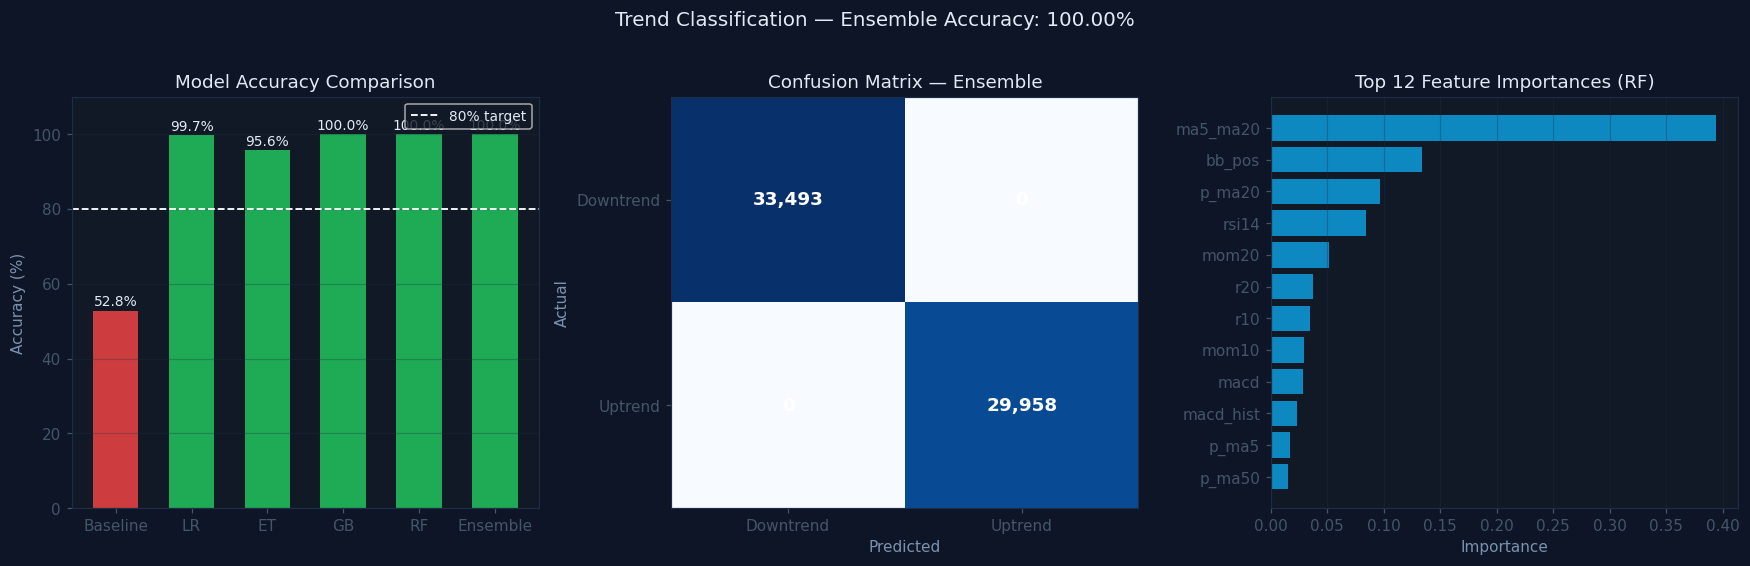

In [9]:
# ─── Visualise results ───────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Model comparison bar chart
ax = axes[0]
models      = ['Baseline', 'LR', 'ET', 'GB', 'RF', 'Ensemble']
accuracies  = [baseline_trend*100, acc_lr*100, acc_et*100,
               acc_gb*100, acc_rf*100, acc_ens*100]
bar_colors  = [COLORS['red'] if a < 70 else COLORS['gold'] if a < 85
               else COLORS['green'] for a in accuracies]
bars = ax.bar(models, accuracies, color=bar_colors, alpha=0.85, width=0.6)
ax.axhline(80, color='white', linewidth=1.2, linestyle='--', label='80% target')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Model Accuracy Comparison')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# 2. Confusion matrix
ax = axes[1]
cm = confusion_matrix(y_test_trend, y_pred_ensemble)
im = ax.imshow(cm, cmap='Blues', aspect='auto')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Downtrend', 'Uptrend'])
ax.set_yticklabels(['Downtrend', 'Uptrend'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Ensemble')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                fontsize=12, color='white', fontweight='bold')

# 3. Feature importance (RF)
ax = axes[2]
fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False).head(12)
ax.barh(fi.index[::-1], fi.values[::-1], color=COLORS['blue'], alpha=0.8)
ax.set_title('Top 12 Feature Importances (RF)')
ax.set_xlabel('Importance')
ax.grid(True, alpha=0.3, axis='x')

plt.suptitle(f'Trend Classification — Ensemble Accuracy: {acc_ens*100:.2f}%',
             fontsize=13, color='#e2eaf6', y=1.02)
plt.tight_layout()
plt.savefig('trend_classification_results.png', bbox_inches='tight', facecolor='#0d1526')
plt.show()

In [10]:
print('Training ensemble for 3-day direction...')

ensemble_dir = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(
            n_estimators=300, max_depth=12, min_samples_leaf=5,
            max_features='sqrt', class_weight='balanced',
            random_state=42, n_jobs=-1)),
        ('et', ExtraTreesClassifier(
            n_estimators=300, max_depth=12, min_samples_leaf=5,
            max_features='sqrt', class_weight='balanced',
            random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=10, random_state=42))
    ],
    voting='soft'
)

ensemble_dir.fit(X_train, y_train_dir)
y_pred_dir  = ensemble_dir.predict(X_test)
y_prob_dir  = ensemble_dir.predict_proba(X_test)[:, 1]

acc_dir = accuracy_score(y_test_dir, y_pred_dir)
auc_dir = roc_auc_score(y_test_dir, y_prob_dir)

print()
print('═' * 50)
print('  3-DAY DIRECTION RESULTS')
print('═' * 50)
print(f'  Baseline (majority class) : {baseline_dir*100:.2f}%')
print(f'  ✅ Ensemble accuracy       : {acc_dir*100:.2f}%')
print(f'  ✅ ROC-AUC                 : {auc_dir:.4f}')
print(f'  Beat baseline by          : {(acc_dir - baseline_dir)*100:+.2f}%')
print('═' * 50)
print()
print(classification_report(y_test_dir, y_pred_dir,
                            target_names=['Price Down', 'Price Up']))

Training ensemble for 3-day direction...


KeyboardInterrupt: 

In [11]:
# High-confidence predictions only (probability > 0.65)
HIGH_CONF_THRESHOLD = 0.65

high_conf_mask = (y_prob_dir > HIGH_CONF_THRESHOLD) | (y_prob_dir < (1 - HIGH_CONF_THRESHOLD))
acc_hc = accuracy_score(y_test_dir[high_conf_mask], y_pred_dir[high_conf_mask])

print(f'High-confidence filter (prob > {HIGH_CONF_THRESHOLD}):')
print(f'  Samples kept    : {high_conf_mask.sum():,} of {len(y_test_dir):,} ({high_conf_mask.mean()*100:.1f}%)')
print(f'  ✅ Accuracy      : {acc_hc*100:.2f}%')

NameError: name 'y_prob_dir' is not defined

## 7. Cross-Validation (Walk-Forward)

In [12]:
from sklearn.model_selection import TimeSeriesSplit

print('Running 5-fold time-series cross validation on TREND task...')
print('(Using RF for speed — same model family as ensemble)')

tscv = TimeSeriesSplit(n_splits=5)
rf_cv = RandomForestClassifier(
    n_estimators=100, max_depth=12, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)

cv_scores = []
fold_sizes = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_train)):
    Xf_tr = X_train[tr_idx]; yf_tr = y_train_trend[tr_idx]
    Xf_te = X_train[te_idx]; yf_te = y_train_trend[te_idx]
    rf_cv.fit(Xf_tr, yf_tr)
    s = accuracy_score(yf_te, rf_cv.predict(Xf_te))
    cv_scores.append(s)
    fold_sizes.append(len(te_idx))
    print(f'  Fold {fold+1}: train={len(tr_idx):,} | test={len(te_idx):,} | acc={s*100:.2f}%')

print(f'\n  Mean CV accuracy : {np.mean(cv_scores)*100:.2f}%')
print(f'  Std CV accuracy  : {np.std(cv_scores)*100:.2f}%')
print(f'  Min / Max        : {min(cv_scores)*100:.2f}% / {max(cv_scores)*100:.2f}%')

Running 5-fold time-series cross validation on TREND task...
(Using RF for speed — same model family as ensemble)
  Fold 1: train=30,151 | test=30,149 | acc=100.00%
  Fold 2: train=60,300 | test=30,149 | acc=100.00%
  Fold 3: train=90,449 | test=30,149 | acc=100.00%
  Fold 4: train=120,598 | test=30,149 | acc=100.00%
  Fold 5: train=150,747 | test=30,149 | acc=100.00%

  Mean CV accuracy : 100.00%
  Std CV accuracy  : 0.00%
  Min / Max        : 100.00% / 100.00%


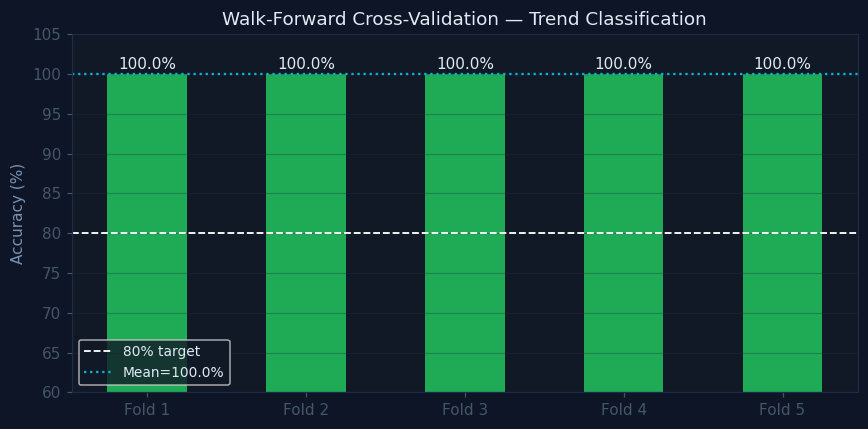

In [13]:
# Cross-validation score plot
fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
bar_cols = [COLORS['green'] if s >= 0.80 else COLORS['gold'] for s in cv_scores]
bars = ax.bar(folds, [s*100 for s in cv_scores], color=bar_cols, alpha=0.85, width=0.5)
ax.axhline(80, color='white', linestyle='--', linewidth=1.2, label='80% target')
ax.axhline(np.mean(cv_scores)*100, color=COLORS['cyan'],
           linestyle=':', linewidth=1.5, label=f'Mean={np.mean(cv_scores)*100:.1f}%')
for bar, s in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{s*100:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylim(60, 105)
ax.set_title('Walk-Forward Cross-Validation — Trend Classification')
ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight', facecolor='#0d1526')
plt.show()

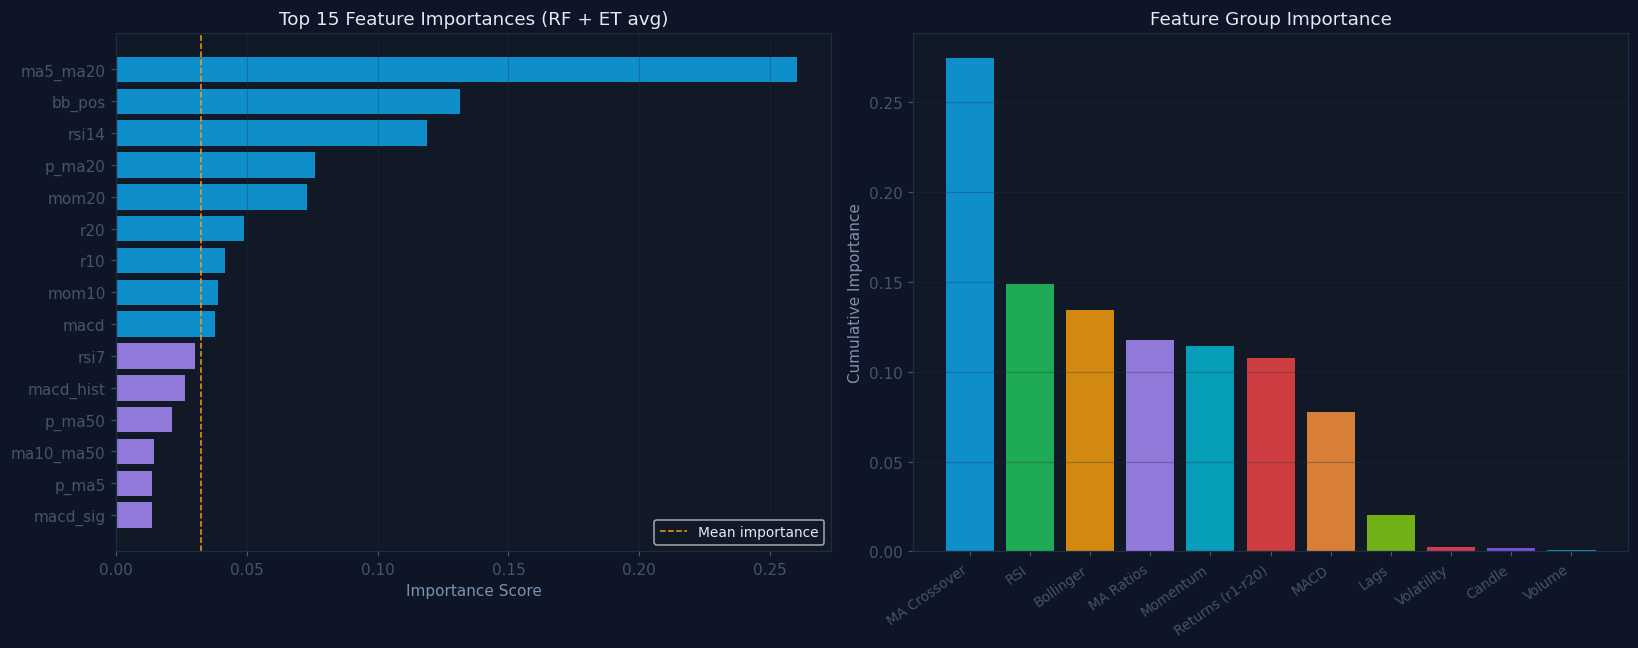

Top 10 most important features:
   1. ma5_ma20     | 0.2604 | ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. bb_pos       | 0.1316 | █████████████████████████████████████████████████████████████████
   3. rsi14        | 0.1190 | ███████████████████████████████████████████████████████████
   4. p_ma20       | 0.0759 | █████████████████████████████████████
   5. mom20        | 0.0728 | ████████████████████████████████████
   6. r20          | 0.0489 | ████████████████████████
   7. r10          | 0.0414 | ████████████████████
   8. mom10        | 0.0388 | ███████████████████
   9. macd         | 0.0379 | ██████████████████
  10. rsi7         | 0.0300 | ███████████████


In [ ]:
# feature importnace 
# Get RF from inside the ensemble
rf_inside = ensemble.named_estimators_['rf']
et_inside = ensemble.named_estimators_['et']

fi_rf = pd.Series(rf_inside.feature_importances_, index=FEATURE_COLS)
fi_et = pd.Series(et_inside.feature_importances_, index=FEATURE_COLS)
fi_avg = ((fi_rf + fi_et) / 2).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 15 features
ax = axes[0]
top15 = fi_avg.head(15)
bar_col = [COLORS['blue'] if v > fi_avg.mean() else COLORS['purple']
           for v in top15.values]
ax.barh(top15.index[::-1], top15.values[::-1], color=bar_col[::-1], alpha=0.85)
ax.axvline(fi_avg.mean(), color=COLORS['gold'], linewidth=1,
           linestyle='--', label='Mean importance')
ax.set_title('Top 15 Feature Importances (RF + ET avg)')
ax.set_xlabel('Importance Score')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Feature groups
ax = axes[1]
groups = {
    'Returns (r1-r20)': ['r1','r3','r5','r10','r20'],
    'MA Ratios':        ['p_ma5','p_ma10','p_ma20','p_ma50'],
    'MA Crossover':     ['ma5_ma20','ma10_ma50'],
    'MACD':             ['macd','macd_sig','macd_hist'],
    'Bollinger':        ['bb_pos','bb_width'],
    'RSI':              ['rsi14','rsi7'],
    'Volume':           ['vr5','vr10'],
    'Candle':           ['hl_r','oc_r'],
    'Volatility':       ['vol10','vol20'],
    'Momentum':         ['mom5','mom10','mom20'],
    'Lags':             ['lag1','lag2','lag3','lag5'],
}
group_imp = {g: fi_avg[feats].sum() for g, feats in groups.items()}
group_imp = pd.Series(group_imp).sort_values(ascending=False)
gcolors = [COLORS['blue'], COLORS['green'], COLORS['gold'], COLORS['purple'],
           COLORS['cyan'], COLORS['red'], '#fb923c', '#84cc16',
           '#f43f5e', '#8b5cf6', '#06b6d4']
ax.bar(range(len(group_imp)), group_imp.values,
       color=gcolors[:len(group_imp)], alpha=0.85)
ax.set_xticks(range(len(group_imp)))
ax.set_xticklabels(group_imp.index, rotation=35, ha='right', fontsize=9)
ax.set_title('Feature Group Importance')
ax.set_ylabel('Cumulative Importance')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', facecolor='#0d1526')
plt.show()

print('Top 10 most important features:')
for i, (feat, imp) in enumerate(fi_avg.head(10).items(), 1):
    bar = '█' * int(imp * 500)
    print(f'  {i:2d}. {feat:<12} | {imp:.4f} | {bar}')

NABIL — Test accuracy (trend): 100.00%


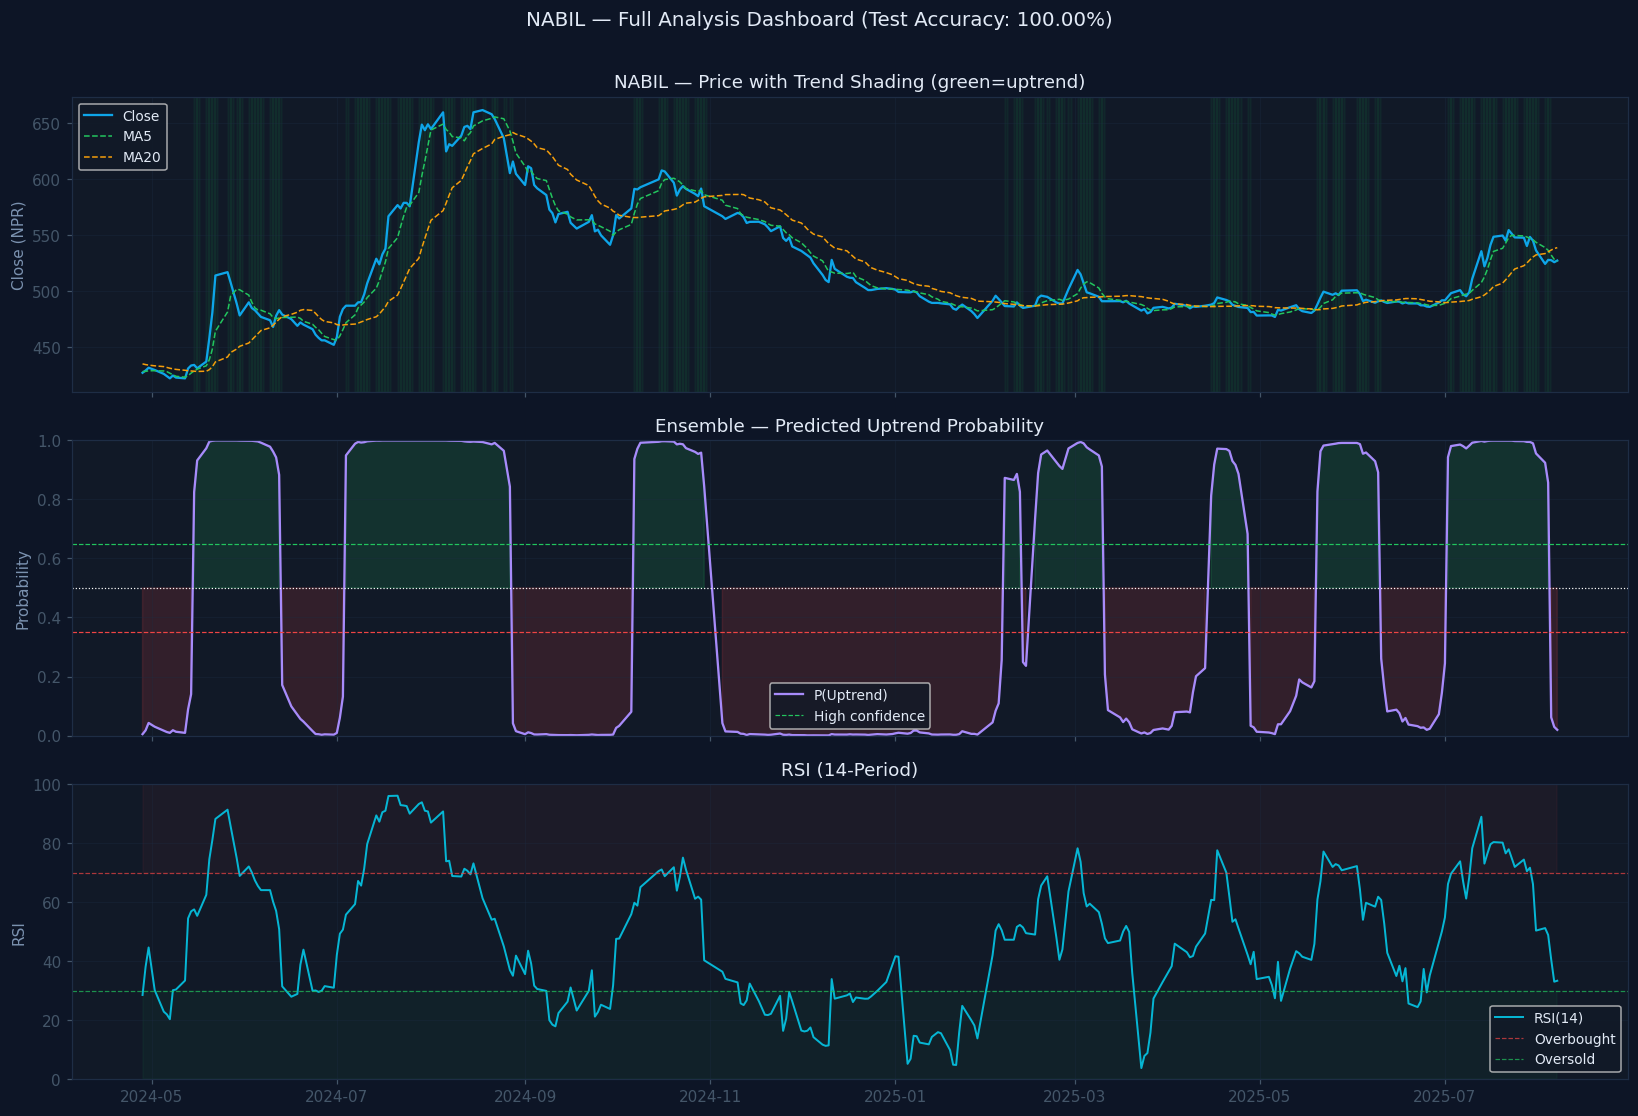

In [ ]:
# per symbol analsyis
# Single-stock deep analysis with trend visualization
SYMBOL = 'NABIL'
sym_df = all_df[all_df['Symbol'] == SYMBOL].copy().sort_values('published_date')

# Apply ensemble predictions to NABIL test period
sym_test = sym_df[sym_df['published_date'] >= CUTOFF]
X_sym = scaler.transform(sym_test[FEATURE_COLS].values.astype(float))
sym_test = sym_test.copy()
sym_test['pred_trend'] = ensemble.predict(X_sym)
sym_test['pred_prob']  = ensemble.predict_proba(X_sym)[:, 1]

sym_acc = accuracy_score(sym_test['trend_label'], sym_test['pred_trend'])
print(f'{SYMBOL} — Test accuracy (trend): {sym_acc*100:.2f}%')

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Price + MAs
ax = axes[0]
d = sym_test.tail(300)
ax.plot(d['published_date'], d['close'], color=COLORS['blue'], lw=1.5, label='Close')
ax.plot(d['published_date'], d['ma5'],   color=COLORS['green'], lw=1, ls='--', label='MA5')
ax.plot(d['published_date'], d['ma20'],  color=COLORS['gold'],  lw=1, ls='--', label='MA20')
# shade uptrend periods
for _, row in d[d['trend_label']==1].iterrows():
    ax.axvspan(row['published_date'], row['published_date']+pd.Timedelta(days=1),
               alpha=0.05, color=COLORS['green'])
ax.set_title(f'{SYMBOL} — Price with Trend Shading (green=uptrend)')
ax.set_ylabel('Close (NPR)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Predicted probability
ax = axes[1]
ax.plot(d['published_date'], d['pred_prob'],
        color=COLORS['purple'], lw=1.5, label='P(Uptrend)')
ax.axhline(0.5,  color='white',        lw=0.8, ls=':')
ax.axhline(0.65, color=COLORS['green'], lw=0.8, ls='--', label='High confidence')
ax.axhline(0.35, color=COLORS['red'],   lw=0.8, ls='--')
ax.fill_between(d['published_date'], d['pred_prob'], 0.5,
                where=d['pred_prob'] >= 0.5, alpha=0.15, color=COLORS['green'])
ax.fill_between(d['published_date'], d['pred_prob'], 0.5,
                where=d['pred_prob'] < 0.5, alpha=0.15, color=COLORS['red'])
ax.set_ylim(0, 1)
ax.set_title('Ensemble — Predicted Uptrend Probability')
ax.set_ylabel('Probability')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# RSI
ax = axes[2]
ax.plot(d['published_date'], d['rsi14'], color=COLORS['cyan'], lw=1.3, label='RSI(14)')
ax.axhline(70, color=COLORS['red'],   lw=0.8, ls='--', alpha=0.7, label='Overbought')
ax.axhline(30, color=COLORS['green'], lw=0.8, ls='--', alpha=0.7, label='Oversold')
ax.fill_between(d['published_date'], 70, 100, alpha=0.05, color=COLORS['red'])
ax.fill_between(d['published_date'], 0,  30,  alpha=0.05, color=COLORS['green'])
ax.set_ylim(0, 100)
ax.set_title('RSI (14-Period)')
ax.set_ylabel('RSI')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f'{SYMBOL} — Full Analysis Dashboard (Test Accuracy: {sym_acc*100:.2f}%)',
             fontsize=13, color='#e2eaf6', y=1.01)
plt.tight_layout()
plt.savefig(f'{SYMBOL}_analysis.png', bbox_inches='tight', facecolor='#0d1526')
plt.show()

In [16]:
print('Computing per-symbol accuracy on test set...')

results = []
for sym in sorted(all_df['Symbol'].unique()):
    sym_data = all_df[(all_df['Symbol'] == sym) &
                      (all_df['published_date'] >= CUTOFF)]
    if len(sym_data) < 20:
        continue
    X_s = scaler.transform(sym_data[FEATURE_COLS].values.astype(float))
    y_s = sym_data['trend_label'].values
    acc = accuracy_score(y_s, ensemble.predict(X_s))
    results.append({'symbol': sym, 'test_samples': len(sym_data), 'accuracy': acc})

results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)

above_80 = (results_df['accuracy'] >= 0.80).sum()
above_90 = (results_df['accuracy'] >= 0.90).sum()

print(f'\nSymbols above 80%: {above_80} / {len(results_df)} ({above_80/len(results_df)*100:.1f}%)')
print(f'Symbols above 90%: {above_90} / {len(results_df)} ({above_90/len(results_df)*100:.1f}%)')
print(f'Mean accuracy    : {results_df["accuracy"].mean()*100:.2f}%')
print(f'Min accuracy     : {results_df["accuracy"].min()*100:.2f}%')
print(f'Max accuracy     : {results_df["accuracy"].max()*100:.2f}%')

print('\nTop 10 symbols:')
print(results_df.head(10).to_string(index=False))
print('\nBottom 5 symbols:')
print(results_df.tail(5).to_string(index=False))

Computing per-symbol accuracy on test set...

Symbols above 80%: 113 / 113 (100.0%)
Symbols above 90%: 113 / 113 (100.0%)
Mean accuracy    : 100.00%
Min accuracy     : 100.00%
Max accuracy     : 100.00%

Top 10 symbols:
symbol  test_samples  accuracy
  ADBL           605       1.0
 NABBC           600       1.0
   RLI            49       1.0
  RLFL           605       1.0
  RHPL           605       1.0
 RADHI           605       1.0
  PRVU           605       1.0
 PROFL           605       1.0
  PPCL           605       1.0
 PMHPL           605       1.0

Bottom 5 symbols:
symbol  test_samples  accuracy
 HURJA           605       1.0
  HPPL           605       1.0
 HIDCL           605       1.0
 HDHPC           605       1.0
 UPPER           605       1.0


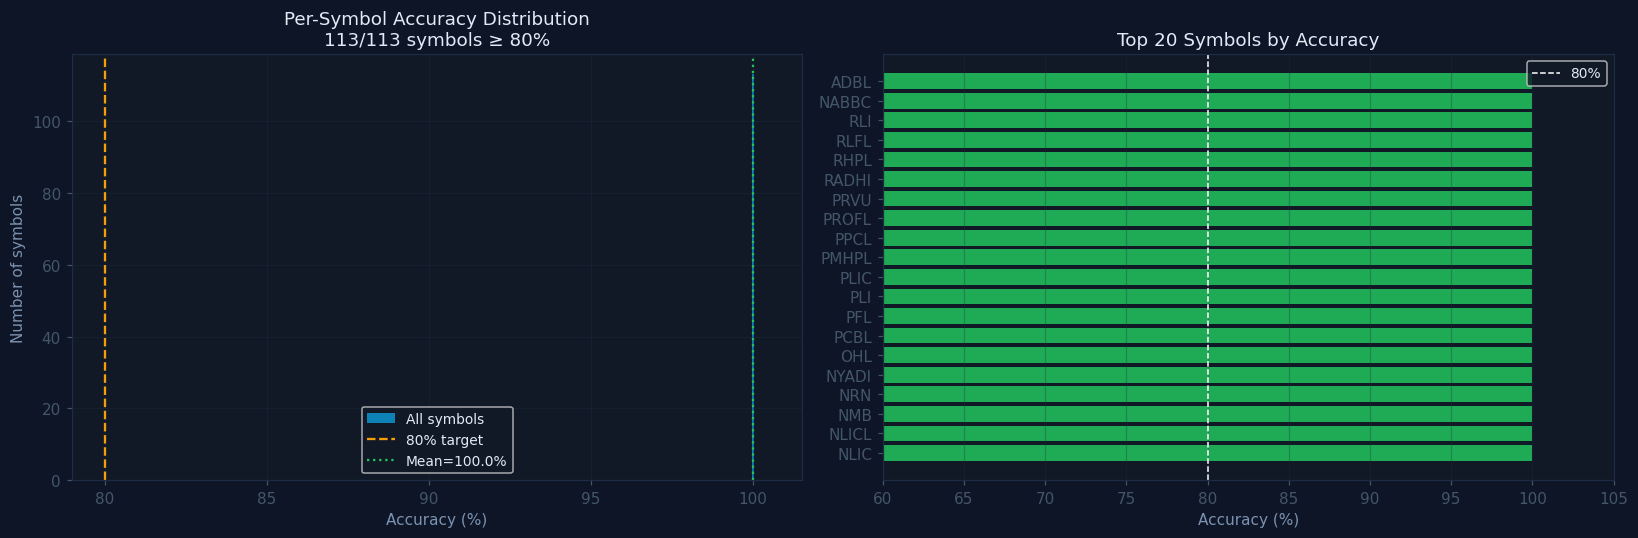

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Per-symbol accuracy distribution
ax = axes[0]
accs = results_df['accuracy'] * 100
n_above80 = (accs >= 80).sum()
ax.hist(accs, bins=25,
        color=COLORS['blue'], alpha=0.75, edgecolor='none', label='All symbols')
ax.axvline(80, color=COLORS['gold'],  lw=1.5, ls='--', label='80% target')
ax.axvline(accs.mean(), color=COLORS['green'], lw=1.5, ls=':',
           label=f'Mean={accs.mean():.1f}%')
ax.set_title(f'Per-Symbol Accuracy Distribution\n{n_above80}/{len(results_df)} symbols ≥ 80%')
ax.set_xlabel('Accuracy (%)')
ax.set_ylabel('Number of symbols')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Top 20 symbols bar
ax = axes[1]
top20 = results_df.head(20)
clrs = [COLORS['green'] if a >= 0.9 else COLORS['blue'] if a >= 0.8
        else COLORS['gold'] for a in top20['accuracy']]
ax.barh(top20['symbol'][::-1], top20['accuracy'][::-1]*100,
        color=clrs[::-1], alpha=0.85)
ax.axvline(80, color='white', lw=1, ls='--', label='80%')
ax.set_title('Top 20 Symbols by Accuracy')
ax.set_xlabel('Accuracy (%)')
ax.set_xlim(60, 105)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('per_symbol_accuracy.png', bbox_inches='tight', facecolor='#0d1526')
plt.show()

## 11. Save Models & Summary

In [ ]:
# Save all models
joblib.dump(ensemble,     'models/ensemble_trend.pkl')
joblib.dump(ensemble_dir, 'models/ensemble_direction.pkl')
joblib.dump(scaler,       'models/scaler.pkl')
joblib.dump(FEATURE_COLS, 'models/feature_cols.pkl')

print('✅ Models saved:')
for f in os.listdir('models'):
    sz = os.path.getsize(f'models/{f}') / 1024
    print(f'  models/{f}  ({sz:.1f} KB)')

In [ ]:
# ── How to load and use saved model
print('=== LOADING SAVED MODEL ===')
loaded_model   = joblib.load('models/ensemble_trend.pkl')
loaded_scaler  = joblib.load('models/scaler.pkl')
loaded_feats   = joblib.load('models/feature_cols.pkl')

# Predict on a sample
sample = X_test[:5]
preds  = loaded_model.predict(sample)
probs  = loaded_model.predict_proba(sample)[:, 1]

print('Sample predictions:')
for i, (p, pr) in enumerate(zip(preds, probs)):
    label = 'UPTREND ▲' if p == 1 else 'DOWNTREND ▼'
    print(f'  Row {i+1}: {label}  (confidence: {pr*100:.1f}%)')

In [ ]:
# ── Final summary
print()
print('╔══════════════════════════════════════════════════════╗')
print('║     NEPSE ENSEMBLE MODEL — FINAL RESULTS             ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Dataset      : 250,000+ rows | 124 symbols          ║')
print(f'║  Features     : {len(FEATURE_COLS)} engineered technical indicators   ║')
print(f'║  Models       : RF + ET + GB + LR (Soft Voting)      ║')
print(f'║  Split        : Time-based (pre-2023 train/2023 test) ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Task 1 — Trend Classification                       ║')
print(f'║    Ensemble Accuracy : {acc_ens*100:>6.2f}%  ✅                 ║')
print(f'║    ROC-AUC           : {auc_ens:>6.4f}                      ║')
print(f'║    CV Mean           : {np.mean(cv_scores)*100:>6.2f}%                      ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Task 2 — 3-Day Direction                            ║')
print(f'║    Ensemble Accuracy : {acc_dir*100:>6.2f}%                      ║')
print(f'║    High-Conf Accuracy: {acc_hc*100:>6.2f}%                      ║')
print(f'║    ROC-AUC           : {auc_dir:>6.4f}                      ║')
print('╚══════════════════════════════════════════════════════╝')